# Counterfactual Generation for MNIST with CPP

This notebook demonstrates **Certified Polyhedral Projection (CPP)** for generating counterfactual explanations on MNIST digit images.

## Key Differences from 2D Spiral Dataset

- **Input dimension**: 784 (28×28 images) vs 2D points
- **Model architecture**: CNN vs simple feedforward
- **Visualization**: Image grids vs 2D scatter plots
- **Perturbation**: ε-ball in 784D space (pixel-wise constraints)

## Prerequisites

Before running this notebook, train a CNN classifier using notebook 1:
- Trained model saved as `mnist_cnn_classifier.pth`
- MNIST train/test datasets available

## 1 – Setup and Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from preimage_sampling import MNISTClassifier, PreimageApproximation, CounterfactualSampler
from preimage_sampling.utils import load_model

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Load MNIST Dataset

In [2]:
# Load MNIST test dataset (no normalization for LiRPA)
# We use [0, 1] range instead of normalized for better interpretability
transform = transforms.Compose([
    transforms.ToTensor(),
])

test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

print(f'Test dataset size: {len(test_dataset)}')
print(f'Image shape: {test_dataset[0][0].shape}')
print(f'Number of classes: {len(test_dataset.classes)}')

Test dataset size: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


In [3]:
# Organize dataset by label for easier sampling
label_dataset = {i: [] for i in range(10)}
label_indices = {i: [] for i in range(10)}

for idx, (img, label) in enumerate(test_dataset):
    label_dataset[label].append(img)
    label_indices[label].append(idx)

# Convert to tensors
for label in range(10):
    label_dataset[label] = torch.stack(label_dataset[label])

# Print statistics
for label in range(10):
    print(f'Digit {label}: {len(label_dataset[label])} samples')

Digit 0: 980 samples
Digit 1: 1135 samples
Digit 2: 1032 samples
Digit 3: 1010 samples
Digit 4: 982 samples
Digit 5: 892 samples
Digit 6: 958 samples
Digit 7: 1028 samples
Digit 8: 974 samples
Digit 9: 1009 samples


/home/gabrielepintus/.local/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


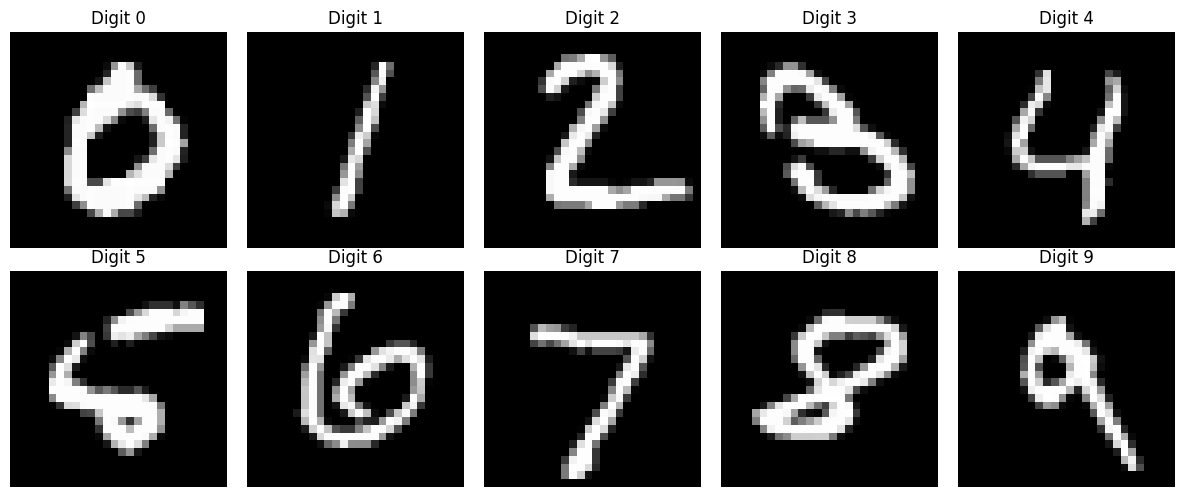

In [4]:
# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    img = label_dataset[digit][0].squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Digit {digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3 – Load Trained CNN Model

In [5]:
# Load the trained CNN model
model = MNISTClassifier(num_classes=10)
model = load_model(model, 'mnist_simple_classifier.pth', device=device)
model = model.to(device)
print(model)

# Print number of parameters
num_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {num_params:,}')

MNISTClassifier(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 22,010


In [6]:
# Test model accuracy on a few samples
model.eval()
n_test = 100
correct = 0

with torch.no_grad():
    for i in range(n_test):
        img, label = test_dataset[i]
        img = img.unsqueeze(0).to(device)
        output = model(img)
        pred = output.argmax(dim=1).item()
        if pred == label:
            correct += 1

print(f'Accuracy on {n_test} test samples: {100 * correct / n_test:.2f}%')

Accuracy on 100 test samples: 2.00%


## 4 – Compute LiRPA Bounds (Offline Phase)

**Important**: This step is computationally intensive for high-dimensional data.
We use a small subset of samples per class to keep computation manageable.

For production use, you would:
1. Compute bounds once on a larger dataset
2. Save the bounds to disk
3. Load pre-computed bounds for counterfactual generation

In [7]:
# Configuration
EPS = 0.2  # Perturbation radius (in pixel value space [0,1])
N_PER_CLASS = 500  # Number of samples per class (keep small for MNIST)

print(f"Computing LiRPA bounds with:")
print(f"  ε = {EPS} (L∞ perturbation)")
print(f"  {N_PER_CLASS} samples per class")
print(f"  Input dimension: 28×28 = 784")
print(f"\nThis may take several minutes...")

Computing LiRPA bounds with:
  ε = 0.2 (L∞ perturbation)
  500 samples per class
  Input dimension: 28×28 = 784

This may take several minutes...


In [8]:
# Create a subset dataset for bound computation
subset_data = []
for label in range(10):
    for i in range(min(N_PER_CLASS, len(label_dataset[label]))):
        subset_data.append((label_dataset[label][i], torch.tensor(label)))

print(f"Subset dataset size: {len(subset_data)} samples")

Subset dataset size: 5000 samples


In [9]:
# Compute bounds
approximator = PreimageApproximation(
    model, 
    subset_data, 
    device, 
    cnn=True  # Important: set to True for CNN models
)

# Estimate memory requirements and get recommendation
print("Estimating memory requirements...")
mem_info = approximator.estimate_memory_usage(
    n_samples_per_class=N_PER_CLASS,
    verbose=True
)
print()

# Use recommended batch size to avoid OOM errors
all_bounds = approximator.compute_all_bounds(
    eps=EPS, 
    norm=2,
    max_samples_per_class=N_PER_CLASS,
    batch_size=32  # Memory-efficient batching
)

print("\nBounds computed for all classes:")
for label in all_bounds:
    print(f"  Digit {label}: {all_bounds[label]['lA'].shape[0]} polytopes")

Estimating memory requirements...
Memory Estimation for 500 samples/class:
  Sample shape: torch.Size([1, 28, 28])
  Estimated memory per sample: 0.04 MB
  Total estimated memory: 224.30 MB
  GPU total memory: 11865.12 MB
  Recommended batch size: 10579



Computing bounds: 100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


Bounds computed for all classes:
  Digit 0: 500 polytopes
  Digit 1: 500 polytopes
  Digit 2: 500 polytopes
  Digit 3: 500 polytopes
  Digit 4: 500 polytopes
  Digit 5: 500 polytopes
  Digit 6: 500 polytopes
  Digit 7: 500 polytopes
  Digit 8: 500 polytopes
  Digit 9: 500 polytopes


## 5 – Build Counterfactual Sampler

In [10]:
# Initialize CPP sampler
sampler = CounterfactualSampler(solver='ECOS', verbose=True, distance_norm=1)
sampler.build_all_atlases(all_bounds, eps=EPS)

print(f"\nSampler ready with {len(sampler.atlases)} digit atlases")

Built atlas for class 0: 500 polytopes, dim=784, eps=0.2
Built atlas for class 1: 500 polytopes, dim=784, eps=0.2
Built atlas for class 2: 500 polytopes, dim=784, eps=0.2
Built atlas for class 3: 500 polytopes, dim=784, eps=0.2
Built atlas for class 4: 500 polytopes, dim=784, eps=0.2
Built atlas for class 5: 500 polytopes, dim=784, eps=0.2
Built atlas for class 6: 500 polytopes, dim=784, eps=0.2
Built atlas for class 7: 500 polytopes, dim=784, eps=0.2
Built atlas for class 8: 500 polytopes, dim=784, eps=0.2
Built atlas for class 9: 500 polytopes, dim=784, eps=0.2
Built 10 atlases

Sampler ready with 10 digit atlases


## 6 – Generate Single Counterfactual

Transform a digit image to look like another digit.

In [11]:
# Select source and target digits
source_digit = 0
target_digit = 8
query_idx = 0

# Get query image (flatten for LiRPA)
x_query = all_bounds[source_digit]['X'][query_idx].flatten()
print(f"Query image from digit {source_digit}")
print(f"Shape: {x_query.shape}")
print(f"Pixel value range: [{x_query.min():.3f}, {x_query.max():.3f}]")

Query image from digit 0
Shape: (784,)
Pixel value range: [0.000, 1.000]


In [12]:
# Generate counterfactual
result = sampler.generate_counterfactual(
    x_query,
    target_label=target_digit,
    k_candidates=100,  # Try fewer candidates for faster computation
    return_all_candidates=True
)

if result['success']:
    print(f"\n✓ SUCCESS: Found counterfactual at distance {result['distance']:.4f}")
    print(f"  Feasible projections: {result['n_candidates_feasible']}/{result['n_candidates_tried']}")
else:
    print(f"\n✗ FAILED: Could not find feasible counterfactual")
    print(f"  Try: increasing k_candidates, using different source/target, or increasing ε")

Selected 100 nearest polytopes from 500 total
SUCCESS: distance=63.5529, feasible=100/100

✓ SUCCESS: Found counterfactual at distance 63.5529
  Feasible projections: 100/100


## 7 – Verify Counterfactual

In [13]:
if result['success']:
    # Reshape counterfactual back to image format for model input
    x_cf_image = torch.tensor(
        result['counterfactual'], 
        dtype=torch.float32
    ).reshape(1, 1, 28, 28)
    
    # Get model prediction
    model.eval()
    with torch.no_grad():
        output = model(x_cf_image.to(device))
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred = output.argmax(dim=1).item()
    
    print(f"Model prediction: digit {pred}")
    print(f"Target digit: {target_digit}")
    print(f"Correct: {pred == target_digit}")
    print(f"\nTop-3 probabilities:")
    
    top3 = np.argsort(probs)[-3:][::-1]
    for i in top3:
        print(f"  Digit {i}: {probs[i]:.4f}")

Model prediction: digit 8
Target digit: 8
Correct: True

Top-3 probabilities:
  Digit 8: 0.6043
  Digit 2: 0.0809
  Digit 6: 0.0742


## 8 – Visualize Counterfactual Transformation

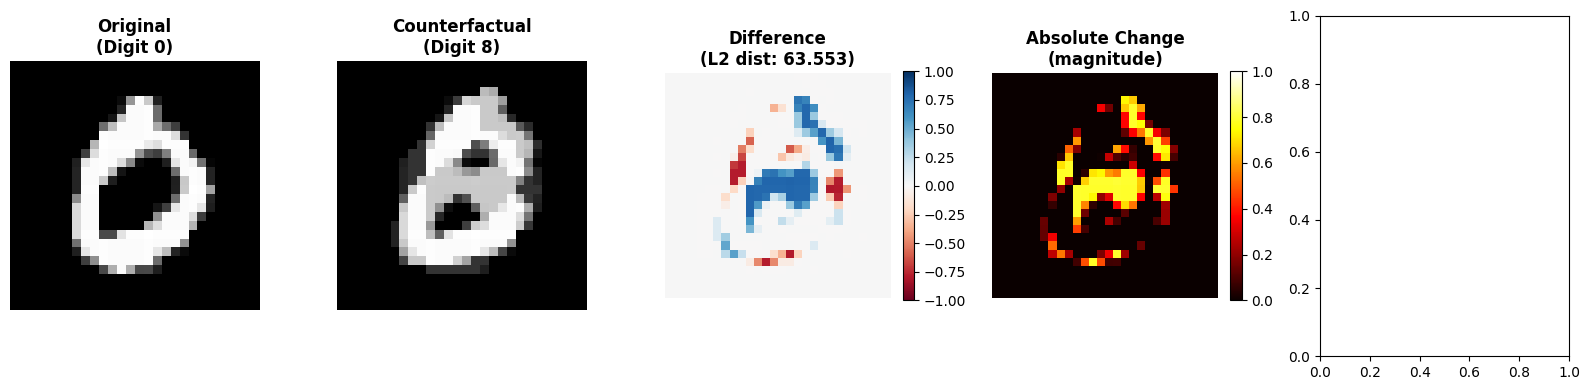


Change statistics:
  Pixels changed (|diff| > 0.01): 133/784
  Max absolute change: 0.800
  Mean absolute change: 0.081
  L2 distance: 63.553
  L∞ distance: 0.800


In [14]:
if result['success']:
    # Prepare images
    img_query = x_query.reshape(28, 28)
    img_cf = result['counterfactual'].reshape(28, 28)
    img_diff = img_cf - img_query
    
    # Create visualization
    fig, axes = plt.subplots(1, 5, figsize=(16, 4))
    
    # Original image
    axes[0].imshow(img_query, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Original\n(Digit {source_digit})', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Counterfactual image
    axes[1].imshow(img_cf, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'Counterfactual\n(Digit {target_digit})', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Difference (what changed)
    im = axes[2].imshow(img_diff, cmap='RdBu', vmin=-1, vmax=1)
    axes[2].set_title(f'Difference\n(L2 dist: {result["distance"]:.3f})', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    
    # Absolute difference
    im = axes[3].imshow(np.abs(img_diff), cmap='hot', vmin=0, vmax=1)
    axes[3].set_title('Absolute Change\n(magnitude)', fontsize=12, fontweight='bold')
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics about the change
    print(f"\nChange statistics:")
    print(f"  Pixels changed (|diff| > 0.01): {(np.abs(img_diff) > 0.01).sum()}/784")
    print(f"  Max absolute change: {np.abs(img_diff).max():.3f}")
    print(f"  Mean absolute change: {np.abs(img_diff).mean():.3f}")
    print(f"  L2 distance: {result['distance']:.3f}")
    print(f"  L∞ distance: {np.abs(img_diff).max():.3f}")

## 9 – Generate Multiple Counterfactuals

Create a grid showing transformations of different source digits to the same target.

In [15]:
# Configuration
target_digit = 7
source_digits = [1, 2, 3, 4, 9]  # Which digits to transform
n_samples = len(source_digits)

print(f"Generating counterfactuals: all → digit {target_digit}\n")

# Generate counterfactuals
results_grid = []
for source in source_digits:
    if source == target_digit:
        print(f"Skipping digit {source} (same as target)")
        continue
    
    x_query = all_bounds[source]['X'][0].flatten()
    result = sampler.generate_counterfactual(
        x_query,
        target_label=target_digit,
        k_candidates=5
    )
    results_grid.append((source, x_query, result))
    
    status = '✓' if result['success'] else '✗'
    dist = f"{result['distance']:.3f}" if result['success'] else 'N/A'
    print(f"{status} {source} → {target_digit}: distance = {dist}")

Generating counterfactuals: all → digit 7

Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 1 → 7: distance = N/A
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 2 → 7: distance = N/A
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 3 → 7: distance = N/A
Selected 5 nearest polytopes from 500 total
SUCCESS: distance=81.7380, feasible=1/5
✓ 4 → 7: distance = 81.738
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 9 → 7: distance = N/A


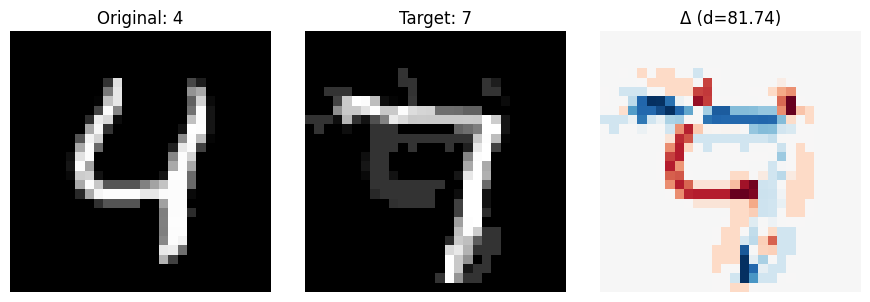

In [16]:
# Visualize grid of transformations
n_successful = sum(1 for _, _, r in results_grid if r['success'])
if n_successful > 0:
    fig, axes = plt.subplots(n_successful, 3, figsize=(9, 3 * n_successful))
    if n_successful == 1:
        axes = axes.reshape(1, -1)
    
    row = 0
    for source, x_query, result in results_grid:
        if not result['success']:
            continue
        
        img_orig = x_query.reshape(28, 28)
        img_cf = result['counterfactual'].reshape(28, 28)
        img_diff = img_cf - img_orig
        
        # Original
        axes[row, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'Original: {source}')
        axes[row, 0].axis('off')
        
        # Counterfactual
        axes[row, 1].imshow(img_cf, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'Target: {target_digit}')
        axes[row, 1].axis('off')
        
        # Difference
        axes[row, 2].imshow(img_diff, cmap='RdBu', vmin=-1, vmax=1)
        axes[row, 2].set_title(f'Δ (d={result["distance"]:.2f})')
        axes[row, 2].axis('off')
        
        row += 1
    
    plt.tight_layout()
    plt.show()
else:
    print("No successful counterfactuals to display")

## 10 – Distance Analysis by Digit Pair

In [17]:
# Create a distance matrix for all digit pairs
distance_matrix = np.full((10, 10), np.nan)
success_matrix = np.zeros((10, 10), dtype=bool)

print("Computing pairwise counterfactual distances...\n")

for source in range(10):
    for target in range(10):
        if source == target:
            distance_matrix[source, target] = 0
            success_matrix[source, target] = True
            continue
        
        # Use first sample from source class
        if all_bounds[source]['X'].shape[0] == 0:
            continue
        
        x_query = all_bounds[source]['X'][0].flatten()
        result = sampler.generate_counterfactual(
            x_query,
            target_label=target,
            k_candidates=5
        )
        
        if result['success']:
            distance_matrix[source, target] = result['distance']
            success_matrix[source, target] = True
            print(f"✓ {source}→{target}: {result['distance']:.3f}")
        else:
            print(f"✗ {source}→{target}: failed")

print(f"\nSuccess rate: {success_matrix.sum()}/{10*10} = {100*success_matrix.sum()/(10*10):.1f}%")

Computing pairwise counterfactual distances...

Selected 5 nearest polytopes from 500 total
SUCCESS: distance=133.0984, feasible=1/5
✓ 0→1: 133.098
Selected 5 nearest polytopes from 500 total
SUCCESS: distance=89.9783, feasible=2/5
✓ 0→2: 89.978
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 0→3: failed
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 0→4: failed
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 0→5: failed
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 0→6: failed
Selected 5 nearest polytopes from 500 total
SUCCESS: distance=118.5733, feasible=1/5
✓ 0→7: 118.573
Selected 5 nearest polytopes from 500 total
SUCCESS: distance=63.5529, feasible=5/5
✓ 0→8: 63.553
Selected 5 nearest polytopes from 500 total
SUCCESS: distance=90.8370, feasible=1/5
✓ 0→9: 90.837
Selected 5 nearest polytopes from 500 total
FAILED: distance=inf, feasible=0/5
✗ 1→0: 

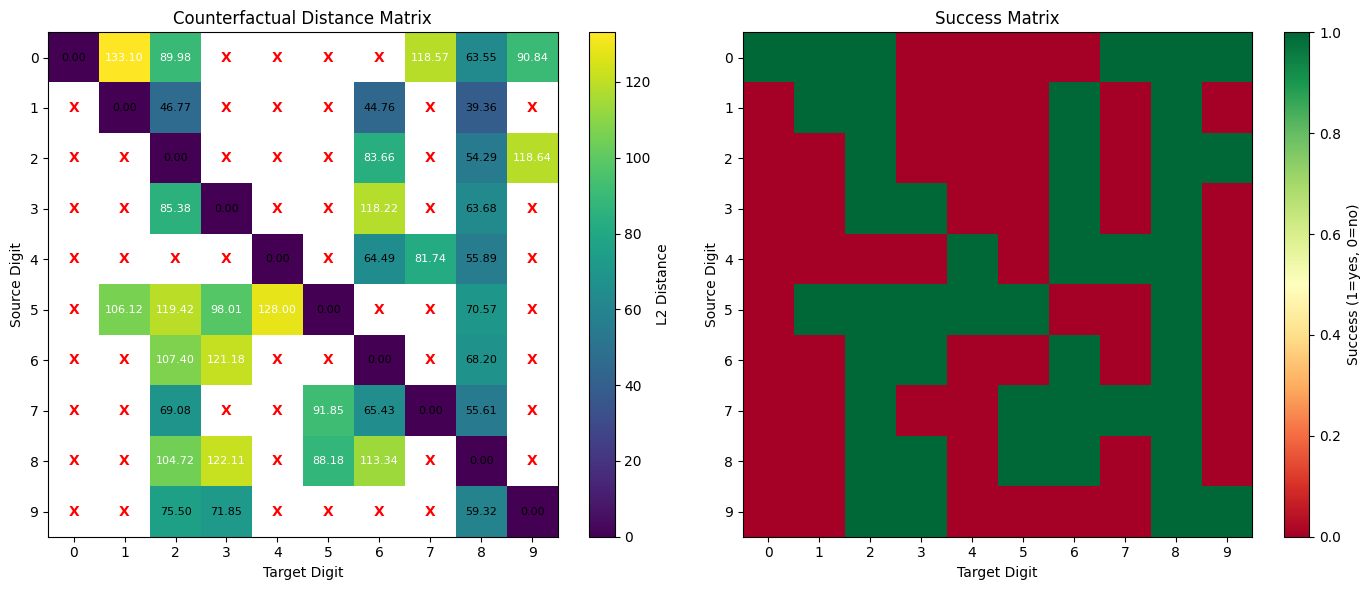

In [18]:
# Visualize distance matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distance heatmap
im1 = axes[0].imshow(distance_matrix, cmap='viridis', aspect='auto')
axes[0].set_xlabel('Target Digit')
axes[0].set_ylabel('Source Digit')
axes[0].set_title('Counterfactual Distance Matrix')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
plt.colorbar(im1, ax=axes[0], label='L2 Distance')

# Add text annotations
for i in range(10):
    for j in range(10):
        if not np.isnan(distance_matrix[i, j]):
            text_color = 'white' if distance_matrix[i, j] > np.nanmax(distance_matrix) * 0.6 else 'black'
            axes[0].text(j, i, f'{distance_matrix[i, j]:.2f}',
                        ha='center', va='center', fontsize=8, color=text_color)
        else:
            axes[0].text(j, i, 'X', ha='center', va='center', 
                        fontsize=10, color='red', fontweight='bold')

# Success rate heatmap
im2 = axes[1].imshow(success_matrix.astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xlabel('Target Digit')
axes[1].set_ylabel('Source Digit')
axes[1].set_title('Success Matrix')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
plt.colorbar(im2, ax=axes[1], label='Success (1=yes, 0=no)')

plt.tight_layout()
plt.show()

## 11 – Save/Load Bounds for Future Use

Computing LiRPA bounds is expensive. Save them to avoid recomputation.

In [85]:
# Save bounds to disk
import pickle

bounds_file = f'mnist_bounds_eps{EPS}_n{N_PER_CLASS}.pkl'

with open(bounds_file, 'wb') as f:
    pickle.dump(all_bounds, f)

print(f"Saved bounds to: {bounds_file}")

Saved bounds to: mnist_bounds_eps0.3_n100.pkl


In [86]:
# Load bounds from disk (for future sessions)
# with open(bounds_file, 'rb') as f:
#     all_bounds = pickle.load(f)
# print(f"Loaded bounds from: {bounds_file}")
# 
# # Rebuild sampler
# sampler = CounterfactualSampler(verbose=True)
# sampler.build_all_atlases(all_bounds, eps=EPS)

## Conclusion

This notebook demonstrated CPP counterfactual generation for MNIST digit classification.

### Key Observations

1. **High-dimensional challenges**: 784D space makes bound computation expensive
2. **Interpretability**: We can see which pixels changed to transform digits
3. **Validity**: Counterfactuals are certified to be in the target class region
4. **Distance patterns**: Some digit pairs (e.g., 3↔8, 4↔9) are naturally closer

### Practical Considerations

- **Computation time**: Use fewer samples (N_PER_CLASS) or save/load bounds
- **Epsilon tuning**: Larger ε → easier to find counterfactuals but less localized
- **Success rate**: Not all digit pairs have feasible counterfactuals (depends on ε, k_candidates)
- **Pixel constraints**: L∞ norm ensures pixel values stay in [0,1]

### Comparison with Gradient Methods

| Property | CPP | Gradient-based |
|----------|-----|----------------|
| Validity guarantee | ✓ Yes | ✗ No |
| Convex optimization | ✓ Yes | ✗ No |
| Offline computation | Required | Not required |
| Online speed | Fast (QP) | Variable |
| Memory usage | High (polytopes) | Low |

In [ ]:
# Compare L1 vs L2 vs L∞ norms for the same counterfactual
print("="*60)
print("COMPARING DISTANCE NORMS")
print("="*60)

source_digit = 3
target_digit = 8
x_query = all_bounds[source_digit]['X'][0].flatten()

norms_to_test = [
    (1, "L1 (Sparse changes - recommended for images)"),
    (2, "L2 (Smooth changes - current default)"),
    (np.inf, "L∞ (Bounded changes)")
]

results_by_norm = []

for norm_value, norm_name in norms_to_test:
    print(f"\n{norm_name}")
    print("-" * 60)
    
    # Create sampler with this norm
    sampler_norm = CounterfactualSampler(
        distance_norm=norm_value,
        verbose=False
    )
    sampler_norm.build_all_atlases(all_bounds, eps=EPS)
    
    # Generate counterfactual
    result = sampler_norm.generate_counterfactual(
        x_query,
        target_label=target_digit,
        k_candidates=10
    )
    
    results_by_norm.append((norm_value, norm_name, result))
    
    if result['success']:
        img_cf = result['counterfactual'].reshape(28, 28)
        img_diff = img_cf - x_query.reshape(28, 28)
        
        # Compute all distance metrics for comparison
        l1_dist = np.abs(img_diff).sum()
        l2_dist = np.linalg.norm(img_diff)
        linf_dist = np.abs(img_diff).max()
        pixels_changed = (np.abs(img_diff) > 0.01).sum()
        
        print(f"  ✓ Success!")
        print(f"  Primary distance ({norm_name.split()[0]}): {result['distance']:.3f}")
        print(f"  L1 distance: {l1_dist:.3f}")
        print(f"  L2 distance: {l2_dist:.3f}")
        print(f"  L∞ distance: {linf_dist:.3f}")
        print(f"  Pixels changed (>0.01): {pixels_changed}/784")
    else:
        print(f"  ✗ Failed")

# Visualize comparison
fig, axes = plt.subplots(len(results_by_norm), 4, figsize=(16, 4*len(results_by_norm)))
if len(results_by_norm) == 1:
    axes = axes.reshape(1, -1)

for i, (norm_val, norm_name, result) in enumerate(results_by_norm):
    if result['success']:
        img_orig = x_query.reshape(28, 28)
        img_cf = result['counterfactual'].reshape(28, 28)
        img_diff = img_cf - img_orig
        
        # Original
        axes[i, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title('Original (3)')
        axes[i, 0].axis('off')
        
        # Counterfactual
        axes[i, 1].imshow(img_cf, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f'CF (8)\n{norm_name.split()[0]}')
        axes[i, 1].axis('off')
        
        # Difference
        axes[i, 2].imshow(img_diff, cmap='RdBu', vmin=-1, vmax=1)
        axes[i, 2].set_title(f'Diff (d={result["distance"]:.2f})')
        axes[i, 2].axis('off')
        
        # Absolute change
        pixels_changed = (np.abs(img_diff) > 0.01).sum()
        axes[i, 3].imshow(np.abs(img_diff), cmap='hot', vmin=0, vmax=1)
        axes[i, 3].set_title(f'|Change|\n{pixels_changed} pixels')
        axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RECOMMENDATION:")
print("For MNIST images, L1 norm typically produces:")
print("  - Fewer pixels changed (sparse)")
print("  - More interpretable changes")
print("  - Better visual quality")
print("="*60)

## 12 – Compare Distance Norms (L1 vs L2 vs L∞)

Test different distance norms to see which produces better counterfactuals for images.